In [15]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import torch

In [ ]:
# def get_pca_anomaly_score(X, n_components=3):
#     """
#     PCA Reconstruction Error.
#     Fits PCA on the current cross-section of stocks. 
#     High MSE = market dynamics for this stock are detached from main linear factors.
#     """
#     # Always scale before PCA
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)
    
#     pca = PCA(n_components=n_components)
#     pca.fit(X_scaled)
    
#     # Transform and reconstruct
#     X_reconstructed = pca.inverse_transform(pca.transform(X_scaled))
    
#     # Calculate Mahalanobis distance (as in paper Anomaly Detection using PCA in Time Series Data) per stock
#     mse = np.mean((X_scaled - X_reconstructed)**2, axis=1)
    
#     # Normalize to [0, 1] for easy comparison with your GAT signals
#     return (mse - mse.min()) / (mse.max() - mse.min() + 1e-8) # size N_stocks 

In [17]:

def train_pca_model(train_features, n_components=3):
    """
    Step 1: Fit the model on 'Normal' data (2012-2016).
    Returns the components and the precision matrix for Mahalanobis.
    """
    # 1. Standardise training data
    mean = train_features.mean(dim=0) # mean across dimension 0 (N) so comparing different stocks
    std = train_features.std(dim=0) + 1e-8 
    X_scaled = (train_features - mean) / std 
    
    # 2. PCA via SVD
    U, S, V = torch.pca_lowrank(X_scaled, q=n_components)
    
    # 3. Get Covariance in PCA space to define the 'Normal' distribution center
    X_pca = torch.matmul(X_scaled, V[:, :n_components])
    pca_mean = X_pca.mean(dim=0)
    centered_pca = X_pca - pca_mean
    cov = torch.mm(centered_pca.t(), centered_pca) / (X_pca.shape[0] - 1)
    inv_cov = torch.linalg.pinv(cov)
    
    # Return everything needed to 'transform' future data
    return {
        'mean': mean, 'std': std, 'V': V[:, :n_components], 
        'pca_mean': pca_mean, 'inv_cov': inv_cov
    }

def get_anomaly_score_oos(test_features, model_params):
    """
    Step 2: Predict anomalies on new data (2019-2024) 
    using the learned historical 'Normal' factors.
    """
    # 1. Scale using TRAIN mean/std (Standardisation)
    X_scaled = (test_features - model_params['mean']) / model_params['std']
    
    # 2. Project onto TRAIN components
    X_pca = torch.matmul(X_scaled, model_params['V'])
    
    # 3. Calculate Mahalanobis distance from the TRAIN center [cite: 590]
    diff = X_pca - model_params['pca_mean']
    left_term = torch.matmul(diff, model_params['inv_cov'])
    mahal_dist = torch.sqrt(torch.sum(left_term * diff, dim=1))
    
    return mahal_dist

In [18]:
print("\n[1/6] Loading data...")
device = torch.device("cpu")

# Load prices
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

all_stocks = prices.columns.tolist()
stock2idx = {s: i for i, s in enumerate(all_stocks)}
idx2stock = {i: s for s, i in stock2idx.items()}
N_full = len(all_stocks)

# Load sectors
sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                        header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes


tickers = prices.columns.get_level_values(0).unique().tolist()
node_map = {ticker: i for i, ticker in enumerate(tickers)}

# Split data: Train 2007-2009, Test 2019-2021
# train_prices = prices.loc['2012-01-01':'2016-12-31']
# test_prices = prices.loc['2019-07-01':'2024-12-31']
# val_prices = prices.loc["2017-01-01":"2019-06-30"]

train_prices = prices.loc[:'2007-05-30']
test_prices = prices.loc['2007-12-31':'2008-12-31']
val_prices = prices.loc["2007-06-01":"2007-12-30"]

returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True) 
returns = returns.pct_change().dropna(how='all')
#returns = returns.ffill().bfill()
# Compute returns
# train_returns = train_prices.pct_change().dropna(how='all')
# test_returns = test_prices.pct_change().dropna(how='all')
train_returns = returns.loc[:'2007-05-30']
train_returns = train_returns.ffill().bfill()
test_returns = returns.loc['2007-12-31':'2008-12-31']
test_returns = test_returns.ffill().bfill()
val_returns = returns.loc["2007-06-01":"2007-12-30"]
val_dates = val_returns.index
all_dates = sorted(set(train_returns.index) | set(test_returns.index) | set(val_returns.index))
test_dates = test_returns.index
train_dates = train_returns.index
# Compute volatility
train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
volatility = pd.concat([train_volatility, test_volatility]).sort_index()

# Helper to load and fix dates
def load_and_fix_index(filename):
    df = pd.read_csv(filename, index_col=0)
    df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
    df.dropna(how='all', inplace=True)
    df = df.ffill().bfill()
    return df

# Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
# Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
# Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
#Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')


[1/6] Loading data...


C:\Users\archi\AppData\Local\Temp\ipykernel_202052\2559957572.py:36: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = returns.pct_change().dropna(how='all')


In [19]:
print('Precomputing Z scores for all features...')

def precompute_zscores(df, window=63):
    """Calculates rolling z-scores for an entire dataframe at once."""
    rolling_mean = df.rolling(window=window, min_periods=5).mean()
    rolling_std = df.rolling(window=window, min_periods=5).std()
    # Avoid division by zero with 1e-8
    z_scores = (df - rolling_mean) / (rolling_std + 1e-8)
    # Clip outliers to keep gradients stable and fill NaNs
    return z_scores.clip(-5.0, 5.0).fillna(0.0)

# Precompute z-scores for all feature dataframes
Z_DATA = {
    'volatility':       precompute_zscores(volatility), # use your vol_window here
    'market_caps':      precompute_zscores(Market_caps),
    'pe_ratios':        precompute_zscores(PE_ratios),
    'implied_vol':      precompute_zscores(Implied_vol),
    #'short_interest':   precompute_zscores(Short_interest),
    'beta':             precompute_zscores(Beta),
    # 'op_margin':        precompute_zscores(Operating_margin),
    # 'roe':              precompute_zscores(Return_on_equity),
    'rsi':              precompute_zscores(RSI_momentum),
    'turnover':         precompute_zscores(Turnover)
}

Precomputing Z scores for all features...


In [20]:

def prepare_node_features(stocks, Z_DATA, t, norm_window=63): # 1 quarter
    """
    Normalise each feature per stock against its own rolling history (z-score),
    preserving signal relative to that stock's recent behaviour.
    """
    rows = []
    t = pd.to_datetime(t)
    
    for stock in stocks:
        
        # Simple lookup instead of rolling calculation
        feats = []
        for key in Z_DATA:
            df = Z_DATA[key]
            val = df.loc[t, stock] if stock in df.columns and t in df.index else 0.0
            feats.append(float(val))
            
        rows.append(feats)

    features = np.array(rows, dtype=np.float32)
    return torch.tensor(np.nan_to_num(features), dtype=torch.float32)

In [21]:

def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]
    #print(f"Window for active stock selection: {window.index.min().date()} to {window.index.max().date()}")
    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    #active = window.columns[ok_obs & ok_nonzero].tolist()
    active = window.columns[ok_nonzero].tolist()
    #print(f"Active stocks before feature intersection: {len(active)}")
    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active

In [ ]:
# We aggregate or average features from the training period to get a stable baseline
K = 21
all_train_features = []
for t in train_dates:
    stocks = get_active_stocks(returns, t, lookback_days=K, feature_dfs=[volatility, Market_caps, PE_ratios, Implied_vol, Beta, RSI_momentum, Turnover], min_obs=21)
    X_t = prepare_node_features(stocks, Z_DATA, t)  # (N_active, 11)
    all_train_features.append(X_t)

# Concatenate rows - shape (sum_of_N_active_across_time, 11)
X_train_combined = torch.cat(all_train_features, dim=0)

torch.manual_seed(42)

# Train PCA on this pooled cross-section
pca_model_params = train_pca_model(X_train_combined, n_components=3)

results = {} 
for t in test_dates:
    # 1. Get the stocks and RAW features for this specific test date
    stocks = get_active_stocks(returns, t, lookback_days=K, feature_dfs=[volatility, Market_caps, PE_ratios, Implied_vol, Beta, RSI_momentum, Turnover], min_obs=21)
    
    # 2. IMPORTANT: Prepare features WITHOUT new normalization to avoid peeking
    # You may need a modified version of this function that doesn't 'fit' new stats
    X_test_scaled = prepare_node_features(stocks, Z_DATA, t)
    
    # 3. Get anomaly scores using the FIXED historical parameters [cite: 505]
    # This function should internally scale X_test using model_params['mean'] and ['std']
    signals = get_anomaly_score_oos(X_test_scaled, pca_model_params)
    
    # 4. Store results: Mapping the date to the stock list and their respective scores
    results[t] = (stocks, signals.cpu().numpy().reshape(-1))

In [23]:
# # want error per stock per time step 
# results = {} # date x stock with PCA anomaly score
# params = {} # t : params
# K = 21
# for t in train_dates:
#     stocks = get_active_stocks(returns, t, lookback_days=K, feature_dfs=[volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover], min_obs=21)
#     X_train = prepare_node_features(stocks, sectors, Z_DATA, t, norm_window=63) # shape (N_stocks, N_features)
#     #print(X.shape)
    
#     params = train_pca_model(X_train, n_components=3)

# for i, t in enumerate(test_dates): 
#     signals = get_anomaly_scores_oos(X_test, params[i])
#     results[t] = stocks, signals.reshape(-1) # signals is now shape (N,)


In [24]:
def evaluate_once(
        test_results,
        prices,
        forward_window,
        crash_threshold
):

    y_true = []
    y_scores = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:

        stocks, signals = test_results[t]

        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()

        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]

        if len(available) == 0:
            continue

        mask = [i for i,s in enumerate(stocks) if s in available]

        signals = signals[mask]

        p_t = prices.loc[t, available]

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]

        p_future = prices.loc[future_date, available]

        fwd_returns = (p_future - p_t) / p_t

        crash = (fwd_returns < crash_threshold).astype(int)

        y_true.extend(crash.values)

        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    auc = roc_auc_score(y_true, y_scores)

    baseline = y_true.mean()

    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()

    lift = precision / baseline if baseline > 0 else np.nan

    return auc, lift, baseline

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline = result

            rows.append({

                "ForwardWindow": fw,

                "CrashThreshold": ct,

                "AUC": auc,

                "Lift": lift,

                "Baseline": baseline

            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
            )

    return pd.DataFrame(rows)

In [25]:
import pandas as pd
import torch
import numpy as np
forward_windows = [10,22]

crash_thresholds = [-0.10,-0.15,-0.20,-0.30]


df_results = grid_search(

    results,

    test_prices,

    forward_windows,

    crash_thresholds

)
# for test_results_test : FW=  5 CT= -0.30 AUC=0.785 Lift=4.45 testing from 2020-2024


FW= 10 CT= -0.10 AUC=0.610 Lift=1.99
FW= 10 CT= -0.15 AUC=0.654 Lift=2.33
FW= 10 CT= -0.20 AUC=0.673 Lift=2.50
FW= 10 CT= -0.30 AUC=0.660 Lift=2.12
FW= 22 CT= -0.10 AUC=0.588 Lift=1.69
FW= 22 CT= -0.15 AUC=0.629 Lift=2.04
FW= 22 CT= -0.20 AUC=0.662 Lift=2.29
FW= 22 CT= -0.30 AUC=0.685 Lift=2.35


In [26]:
import matplotlib.pyplot as plt
print("Visualizing Average Anomaly Signal...")

# 1. Convert the dictionary results into a pandas Series of average scores
# reg_results structure: {date: (active_stocks_list, probabilities_array)}
date_map = {}

for date, (stocks, probs) in results.items():
    # We take the mean of the probabilities for that specific day
    date_map[date] = np.mean(probs)

# Create a Series sorted by date
avg_signals = pd.Series(date_map).sort_index()

# 2. Filter for 2020
try:
    # Slice the series for the year 2020
    avg_signals_2020 = avg_signals.loc['2020-02-13':'2021-01-01']
except KeyError:
    print("Warning: Date range not found in data.")
    avg_signals_2020 = pd.Series()

# 3. Plot
if not avg_signals_2020.empty:
    plt.figure(figsize=(12, 6))

    # Plot directly using the index (dates) and values
    plt.plot(avg_signals_2020.index, avg_signals_2020.values, color='blue', linewidth=2, label='Mean anomaly signal')

    # Highlight COVID Crash
    plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'), 
                color='grey', alpha=0.3, label='COVID Crash')

    plt.title("PCA Anomaly Detection (2020)")
    plt.ylabel("Mean Crash Probability")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 2020.")

Visualizing Average Anomaly Signal...
No data found for 2020.


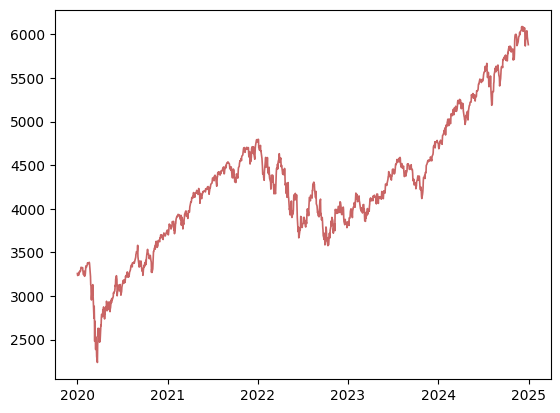

In [27]:
market_data = pd.read_excel('Data/Market_SPX.xlsx', header=0, index_col=0)
market_data_test = market_data.loc['2020-01-01':'2024-12-31']
spx = market_data_test.iloc[:, 0]

plt.plot(spx.index, spx.values, color="firebrick", linewidth=1.2, alpha=0.7, label="SPX")
plt.show()


=== SPX-level AUC (mean signal vs index drops) ===
  FW      CT     AUC    Lift    Base


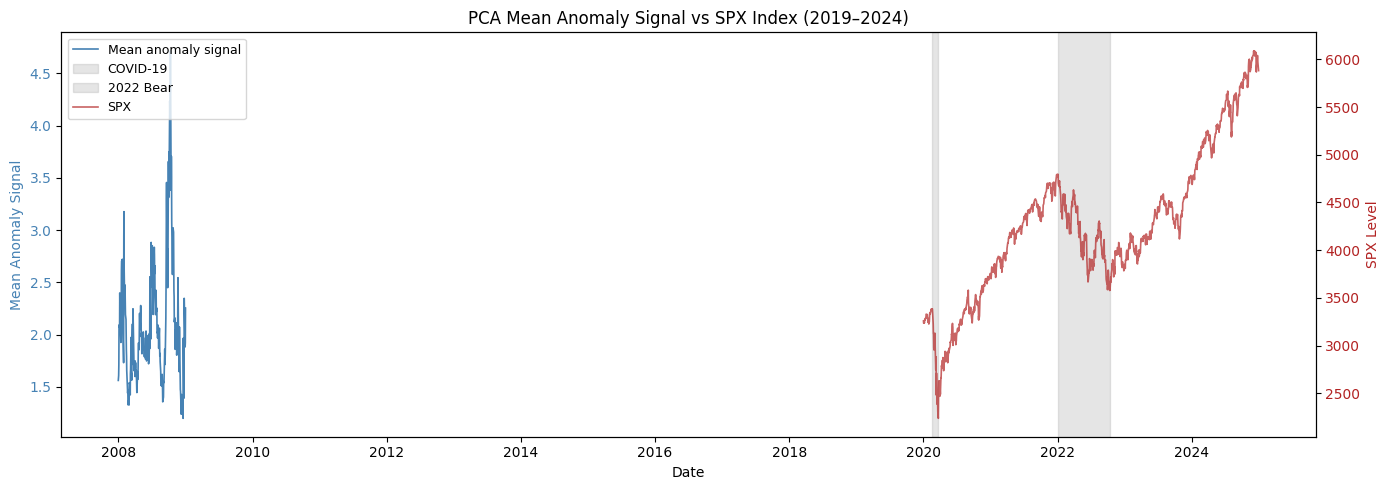

In [28]:
# === AUC: Mean signal vs actual SPX index drops ===

# 1. Build mean signal per date (reuse avg_signals if already computed above)
avg_signals = pd.Series(
    {date: np.mean(probs) for date, (stocks, probs) in results.items()}
).sort_index()

# 2. SPX index level series
spx = market_data_test.iloc[:, 0]  # first column = SPX level

def evaluate_index_auc(avg_signals, spx, forward_window, crash_threshold):
    """AUC where signal = mean per-stock anomaly score, label = SPX drops >= threshold."""
    y_true, y_scores = [], []

    for t in avg_signals.index:
        if t not in spx.index:
            continue
        future_idx = spx.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(spx):
            continue
        fwd_ret = (spx.iloc[future_idx] - spx[t]) / spx[t] # fwd crash? 
        y_true.append(int(fwd_ret < crash_threshold)) # if fwd_crash is more negative than crash threshold then label 1 = crash 
        y_scores.append(avg_signals[t])# add avg signal on that day from model

    y_true, y_scores = np.array(y_true), np.array(y_scores)
    if y_true.sum() == 0:
        return None
    auc = roc_auc_score(y_true, y_scores) 
    baseline = y_true.mean()
    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()
    lift = precision / baseline if baseline > 0 else np.nan
    return auc, lift, baseline

# 3. Grid search
forward_windows  = [10, 22]
crash_thresholds = [-0.10, -0.15, -0.20, -0.30]

print("=== SPX-level AUC (mean signal vs index drops) ===")
print(f"{'FW':>4}  {'CT':>6}  {'AUC':>6}  {'Lift':>6}  {'Base':>6}")
index_rows = []
for fw in forward_windows:
    for ct in crash_thresholds:
        res = evaluate_index_auc(avg_signals, spx, fw, ct)
        if res is None:
            continue
        auc, lift, base = res
        index_rows.append({"ForwardWindow": fw, "CrashThreshold": ct,
                            "AUC": auc, "Lift": lift, "Baseline": base})
        print(f"{fw:4d}  {ct:6.2f}  {auc:6.3f}  {lift:6.2f}  {base:6.3f}")

df_index_results = pd.DataFrame(index_rows)

# 4. Dual-axis plot: mean signal vs SPX level
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel("Date")
ax1.set_ylabel("Mean Anomaly Signal", color="steelblue")
ax1.plot(avg_signals.index, avg_signals.values, color="steelblue", linewidth=1.2, label="Mean anomaly signal")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.set_ylabel("SPX Level", color="firebrick")
ax2.plot(spx.index, spx.values, color="firebrick", linewidth=1.2, alpha=0.7, label="SPX")
ax2.tick_params(axis="y", labelcolor="firebrick")

# Shade known crash periods
crashes = [
    ("COVID-19",  "2020-02-20", "2020-03-23"),
    ("2022 Bear", "2022-01-03", "2022-10-12"),
]
for label, start, end in crashes:
    ax1.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="grey", alpha=0.2, label=label)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
plt.title("PCA Mean Anomaly Signal vs SPX Index (2019–2024)")
plt.tight_layout()
plt.show()
